In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import missingno as msno

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline, FunctionTransformer
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
#from utils.perm_class import ClassificationCV
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression, RidgeClassifier

Using 10% of data (stratified & randomized) for EDA, when fitting model, yield

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

server = '.\SQLEXPRESS' 
database = 'ClubLoanData'

connection_url = (
    "mssql+pyodbc:///?odbc_connect="
    f"DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;"
)

engine = create_engine(connection_url)

try:
    query = """SELECT * FROM (
    SELECT TOP 10 PERCENT * FROM dbo.loan_model_ready 
    WHERE predictor = 1 
    ORDER BY NEWID()) AS Defaults

UNION ALL

SELECT * FROM (
    SELECT TOP 10 PERCENT * FROM dbo.loan_model_ready 
    WHERE predictor = 0 
    ORDER BY NEWID()) AS GoodLoans
"""
    df = pd.read_sql(query, engine)
    df.to_csv('Data/loan_data_sample.csv')
    print(f"Data Shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}")

In [2]:

df = pd.read_csv('Data\loan_data_sample.csv')
features = ['loan_amnt', 'term', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'addr_state', 'is_currently_delinq', 'has_il_history']

index_sql = 'Loan_ID'
target = 'predictor'

df_features  = df[features]
df_predictor = pd.Series(df[target])

#print(df_features.shape,df_predictor.shape)

X_train, X_test, y_train,y_test = train_test_split(df_features,df_predictor,stratify=df_predictor,test_size=.2,random_state=11)

categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Changing the imputed '999' back to NaN for T-Test. This is to make it more straightforward for other Col's with NaN.

In [3]:
imputed_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

for col in imputed_cols:
    X_train[col] = X_train[col].replace(999.0, np.nan)

Target Encoding/Probability Encoding. More effective for highly cardinal data like addr_state. Rest of categorical columns will be OHE. 

- IA had a mean of 0 (no default in training set for IA), we'll use Bayesian smoothing for the whole dataset.

In [4]:
categorical_features = ['home_ownership', 'verification_status', 'application_type', 'addr_state']

X_temp_data = X_train.copy()
X_temp_data['predictor'] = y_train
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
global_default_mean = y_train.mean()

m= 10 #smoothing parameter
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
state_counts = X_temp_data['addr_state'].value_counts()
means_smoothed = ((state_counts*state_means)+(m*global_default_mean))/(state_counts+m)

X_train['state_enc'] = X_train['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['state_enc'].fillna(global_default_mean)
categorical_features.remove('addr_state')

X_encoded=pd.get_dummies(X_train[categorical_features],drop_first=True,sparse=False,dtype=int)
X_train = pd.concat([X_train[numerical_features],X_encoded],axis=1)

X_encoded_test = pd.get_dummies(X_test[categorical_features],drop_first=True,sparse=False,dtype=int)
X_test = pd.concat([X_test[numerical_features],X_encoded_test],axis=1)
#align columns
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)

Pipeline for Flags / missing values

In [5]:
from sklearn import set_config


zero_cols = [
    'max_bal_bc', 'all_util', 'il_util', 'open_acc_6m', 
    'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'inq_last_12m',
    'open_act_il', 'total_bal_il', 'total_il_high_credit_limit', 'is_consolidation'
]

flag_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 
    'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_major_derog'
]

median_cols = [
    'months_sincefrst_credit', 'annual_inc', 'inq_last_6mths', 
    'revol_util', 'total_acc', 'pub_rec', 'open_acc', 
    'mo_sin_old_rev_tl_op', 'num_rev_accts', 'tot_hi_cred_lim',
    'acc_open_past_24mths', 'num_bc_sats', 'num_sats', 'mort_acc',
    'mths_since_recent_bc', 'total_bc_limit', 'pub_rec_bankruptcies',
    'total_rev_hi_lim', 'inq_fi', 'avg_cur_bal', 'bc_open_to_buy', 
    'bc_util', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 
    'num_actv_rev_tl', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 
    'num_rev_tl_bal_gt_0', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'total_cu_tl', 'total_bal_ex_mort', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

set_config(transform_output="pandas")

preprocessing = ColumnTransformer([
    ('zeros',SimpleImputer(strategy='constant',fill_value=0),zero_cols),
    ('flags',SimpleImputer(strategy= 'median',add_indicator=True),flag_cols),
    ('median',SimpleImputer(strategy='median'),median_cols)
],remainder='passthrough')

X_train = preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)


In [6]:

# All features now numerical after pipeline/ target encoding
#categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()


numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Univariate Analysis of features

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

result=[]
for column in numerical_features:
    group1 = X_train[y_train == 0 ][column].dropna()
    group2 = X_train[y_train == 1 ][column].dropna()

    t_stat,p_val = stats.ttest_ind(group1,group2,equal_var=False)

    result.append({'Column':column,'p_val':p_val,
                   'Decision': 'Drop' if p_val > 0.05 else 'Keep'})
    

results = pd.DataFrame(result).sort_values(by='p_val')
print(results)

In [7]:
#print(results[results['Decision']=='Drop']['Column'])

cols_to_drop=['flags__mths_since_last_delinq','median__num_rev_accts','zeros__total_il_high_credit_limit',
              'zeros__is_consolidation','median__num_tl_30dpd','flags__mths_since_last_major_derog',
              'remainder__home_ownership_OWN','flags__mths_since_rcnt_il','remainder__is_currently_delinq',
              'flags__mths_since_recent_bc_dlq','median__total_bal_ex_mort',
              'remainder__home_ownership_OTHER','remainder__home_ownership_NONE','median__num_tl_120dpd_2m','flags__mths_since_last_record']


X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

Feature Engineering

In [8]:
eps = 0.001 # to avoid dividing by zero
# 1. Loan-to-Income
#X_train['FE_loan_to_income'] = X_train['remainder__loan_amnt'] / (X_train['median__annual_inc'] + eps)
#X_test['FE_loan_to_income'] = X_test['remainder__loan_amnt'] / (X_test['median__annual_inc'] + eps)

# 2. Monthly Free Cash Flow
X_train['FE_free_cash_flow'] = (X_train['median__annual_inc'] / 12) * (1 - (X_train['remainder__dti'] / 100))
X_test['FE_free_cash_flow'] = (X_test['median__annual_inc'] / 12) * (1 - (X_test['remainder__dti'] / 100))

# 3. Credit Line Activity Ratio
X_train['FE_activity_ratio'] = X_train['median__num_actv_rev_tl'] / (X_train['median__num_op_rev_tl'] + eps)
X_test['FE_activity_ratio'] = X_test['median__num_actv_rev_tl'] / (X_test['median__num_op_rev_tl'] + eps)

MI/Correlation/ VIF 

In [ ]:
cols_to_drops = [
    'remainder__home_ownership_OWN',
    'median__num_sats',
    'flags__missingindicator_mths_since_last_record',
    'median__pct_tl_nvr_dlq',
    'remainder__public_record',
    'median__total_acc',
    'median__num_rev_accts',
    #SECOND ROUND of drops:
    'median__annual_inc',
    'median__num_rev_tl_bal_gt_0',
    'remainder__tot_cur_bal',
    'median__num_op_rev_tl',
    'remainder__home_ownership_NONE',
    'median__chargeoff_within_12_mths',
    #third and final
    'median__months_sincefrst_credit',
    'median__revol_util',
    'median__num_actv_bc_tl',
    'flags__missingindicator_mths_since_rcnt_il',
    'median__total_bc_limit',
    'median__open_acc',
    'flags__missingindicator_mths_since_recent_revol_delinq',
    'median__num_tl_op_past_12m',
    'median__num_bc_tl'
]

X_train = X_train.drop(columns=cols_to_drops, errors='ignore')
X_test = X_test.drop(columns=cols_to_drops, errors='ignore')

In [41]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 200)  
pd.set_option('display.expand_frame_repr', False) 



vif_list = [variance_inflation_factor(X_train.values, i ) 
              for i in range(len(X_train.columns))]

mi = mutual_info_classif(X_train,y_train,random_state=11)

corr = X_train.corrwith(y_train)
corr = corr.abs()


vmc= pd.DataFrame({
    'feature':X_train.columns,
    'VIF':vif_list,
    'Corr with target': corr.values,
    'Mutual Information': mi
})



vmc = vmc.sort_values(by='VIF',ascending=False).reset_index(drop=True)
print(vmc)


                                                feature        VIF  Corr with target  Mutual Information
0                                       median__bc_util  25.310456          0.071276            0.004328
1                             remainder__has_il_history  20.112435          0.016097            0.012967
2                                       remainder__term  19.207303          0.174618            0.021245
3                                     FE_activity_ratio  17.793271          0.060687            0.003632
4                               median__num_actv_rev_tl  12.666503          0.071175            0.003091
5                                    remainder__purpose  12.280229          0.043038            0.013995
6                               median__tot_hi_cred_lim  11.356792          0.074702            0.003964
7                                       zeros__all_util  10.565285          0.069760            0.003715
8                                   median__num_bc_sats

In [42]:
vif_list = list(vmc[vmc['VIF']>10]['feature'])

print(vif_list)

['median__bc_util', 'remainder__has_il_history', 'remainder__term', 'FE_activity_ratio', 'median__num_actv_rev_tl', 'remainder__purpose', 'median__tot_hi_cred_lim', 'zeros__all_util', 'median__num_bc_sats']


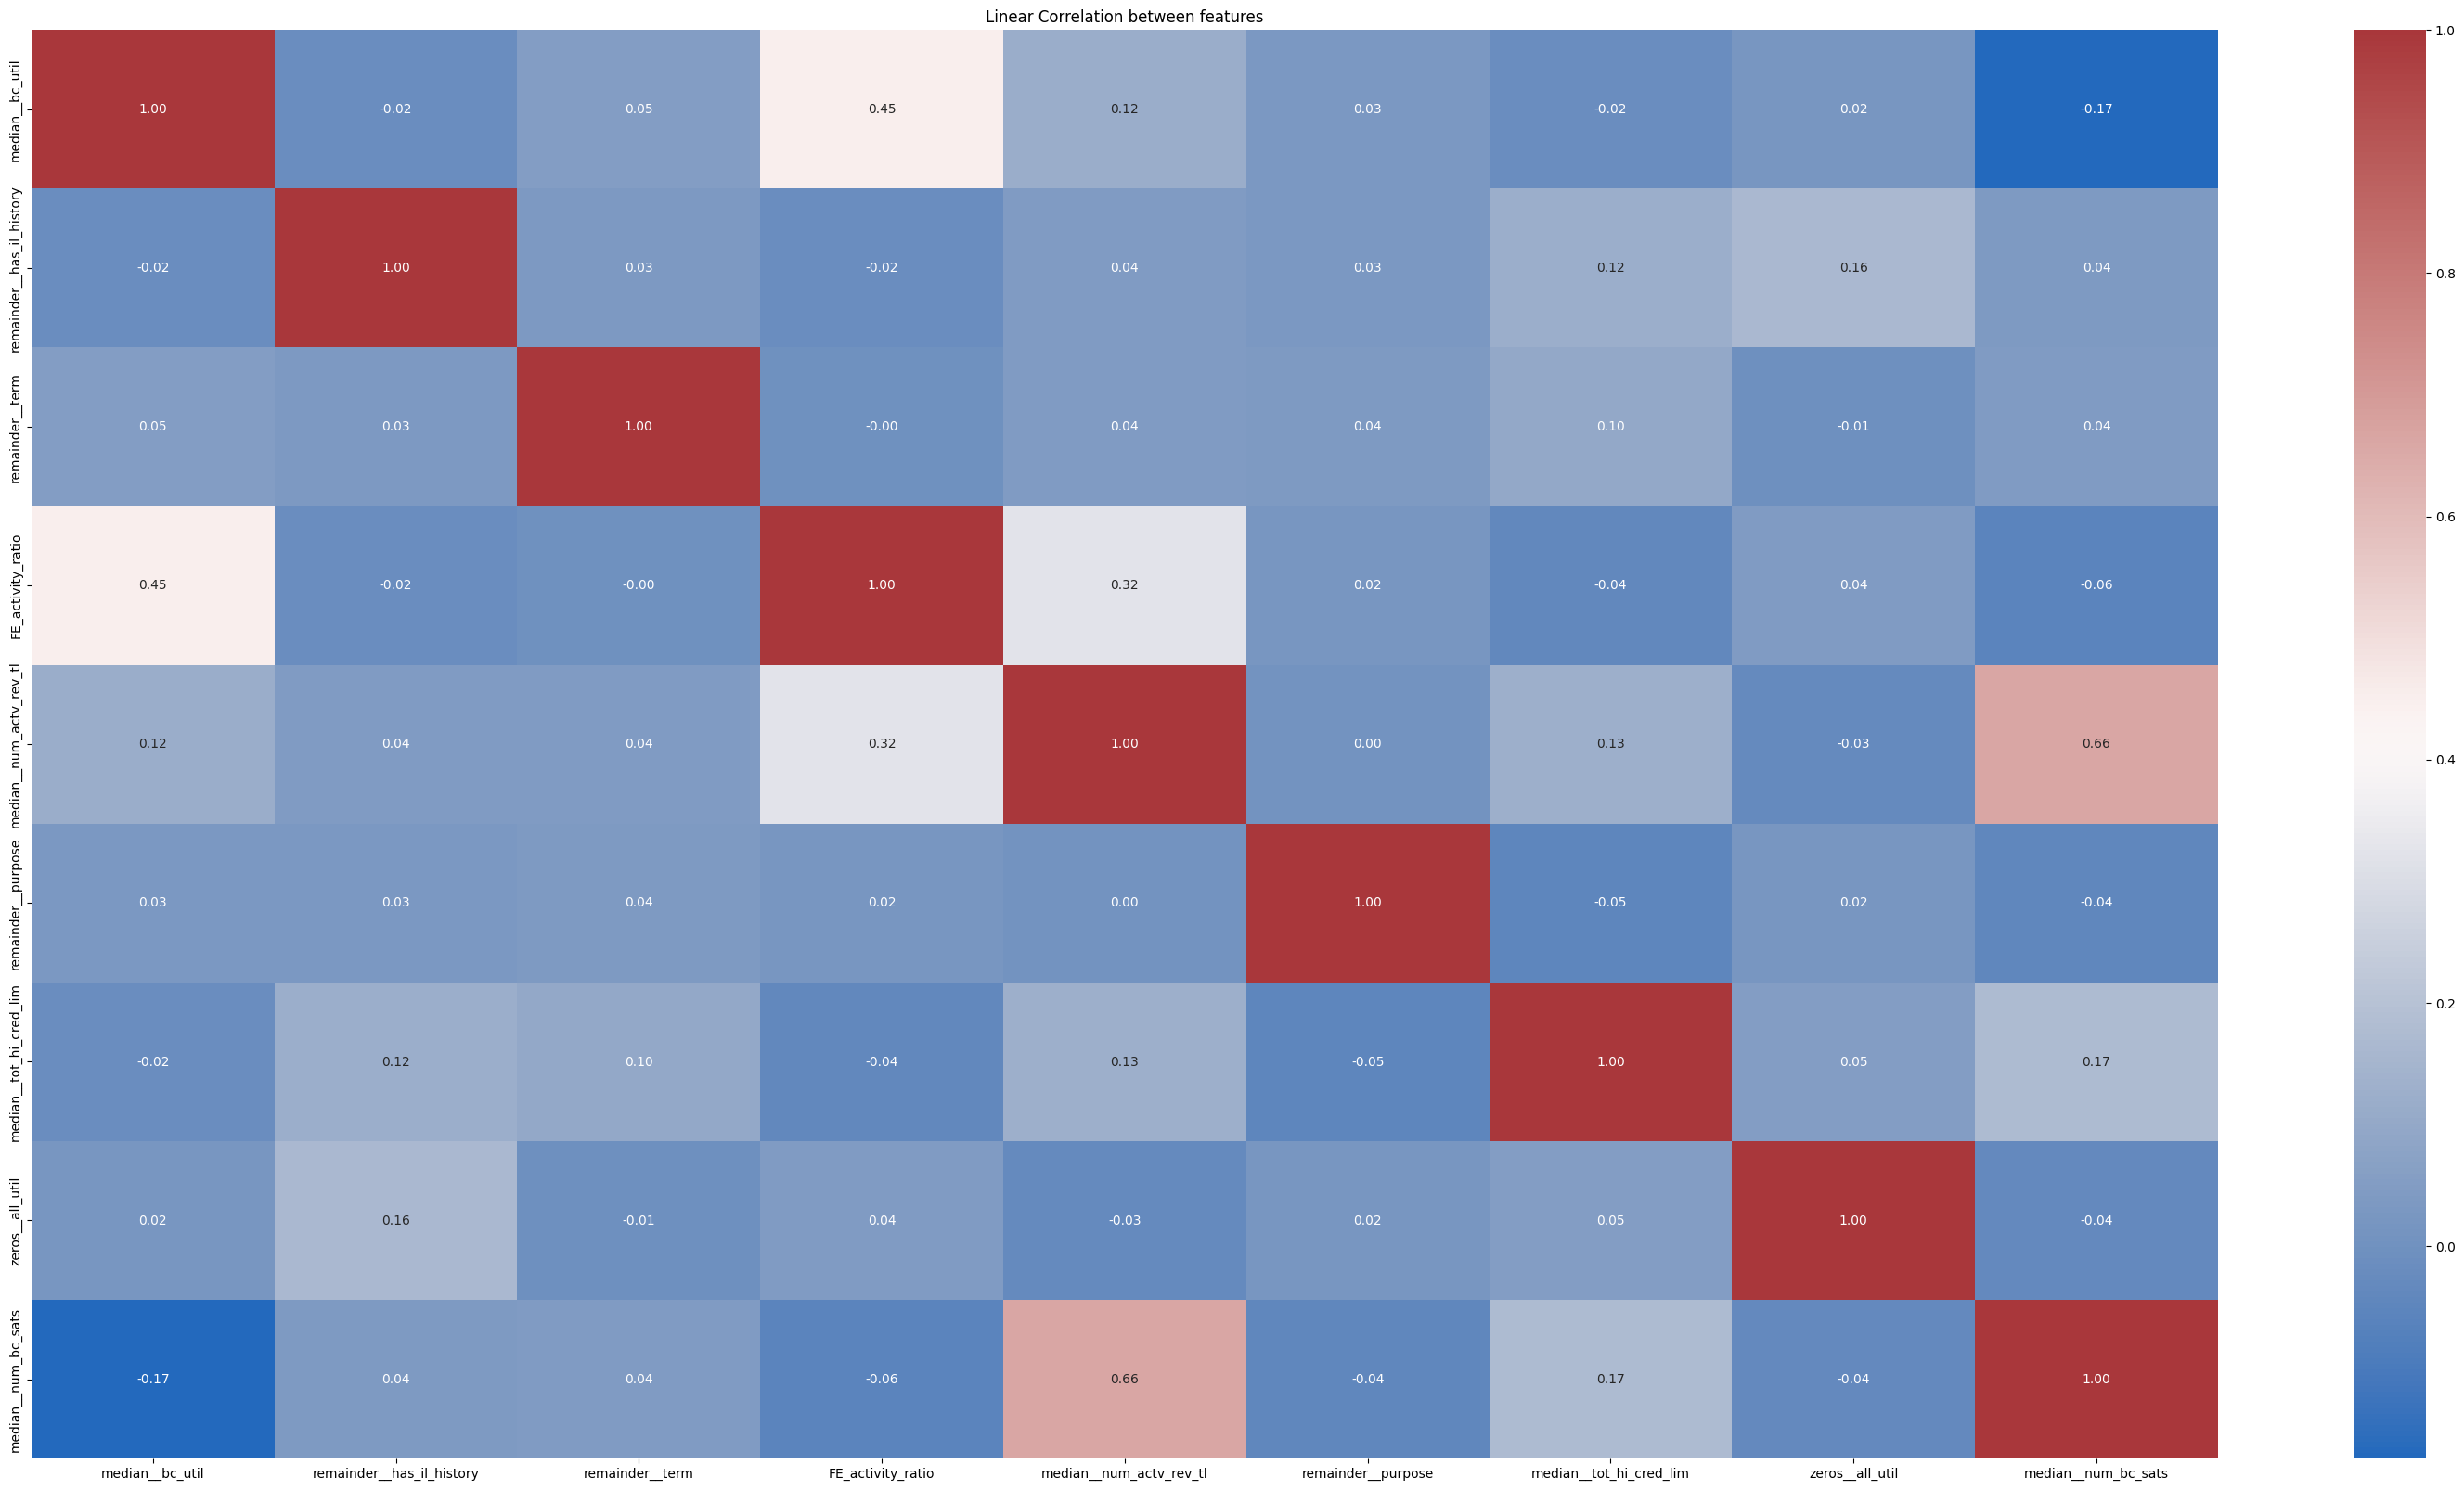

In [43]:


X_cor = X_train[vif_list]
plt.figure(figsize=(38,20))
sns.heatmap(X_cor.corr(numeric_only=True), annot=True,fmt='.2f',cmap='vlag')
plt.title('Linear Correlation between features')

plt.savefig('Images/corr_heatmap2.png',dpi=300,bbox_inches='tight')

plt.show()

Cohen's D and Confidence intervals -- Let's try manual calculation

In [ ]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 200)  
pd.set_option('display.expand_frame_repr', False)

def ci_cohen(X,y):
    df = X.copy()

    df['predictor'] = y

    group_one = df[df['predictor']==1]
    group_zero = df[df['predictor']==0]

    features = X.columns

    results = []
    for i in features:
        g_1 = group_one[i]
        g_0 = group_zero[i]

        n_1 ,n_0 = len(g_1),len(g_0)
        mean_1,mean_0= np.mean(g_1),np.mean(g_0)
        var_1,var_0 = np.var(g_1,ddof=1),np.var(g_0,ddof=1)


        s_pooled = np.sqrt(((n_1-1)* var_1+(n_0-1)*var_0)
                           /(n_1+n_0-2))
        
        d= (mean_1- mean_0)/(s_pooled)

        se_diff = np.sqrt((var_1/n_1)+(var_0/n_0))
        margin_of_error = 1.96*se_diff

        diff_means = mean_1-mean_0
        ci_lower = diff_means - margin_of_error
        ci_upper = diff_means + margin_of_error

        results.append({
            'Feature':i,
            'Cohens d':abs(round(d,2)),
            'CI, (lower,Upper)':f'{round(ci_lower,2)}, {round(ci_upper,2)}',
            'mean difference (default-paid)': round(diff_means,2)
        })
    
    results_df = pd.DataFrame(results).sort_values(by='Cohens d',ascending=False).reset_index(drop=True)

    return(results_df)


cohen_ci = ci_cohen(X_train,y_train)
print(cohen_ci)

                                                Feature  Cohens d     CI, (lower,Upper)  mean difference (default-paid)
0                                       remainder__term      0.44             4.3, 4.64                            4.47
1                                        remainder__dti      0.27             2.14, 2.4                            2.27
2                          median__acc_open_past_24mths      0.24            0.71, 0.81                            0.76
3               remainder__verification_status_Verified      0.22             0.1, 0.11                            0.10
4                                median__bc_open_to_buy      0.21    -3262.21, -2880.07                        -3071.14
5                               median__tot_hi_cred_lim      0.19  -34597.61, -30000.94                       -32299.28
6                                      median__mort_acc      0.19          -0.39, -0.33                           -0.36
7                                    zer

Model + cv  for roc auc 

In [10]:
logreg = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter=1000,random_state=11,class_weight='balanced'))
])

cvr = cross_val_score(logreg,
                      X_train,
                      y_train,
                      cv=5,
                      scoring='roc_auc',
                      n_jobs=-1)

print(cvr)



[0.69828351 0.70495893 0.69929717 0.70222882 0.70082618]


weights -> plots

In [13]:
logreg.fit(X_train,y_train)
model  = logreg.named_steps['model']
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)


features=X_train.columns

model_results = pd.DataFrame({
    'Feature':features,
    'Coef':coefs,
    'odds':odds_ratios
})
mr = model_results.sort_values(by='odds').reset_index(drop=True)
print(mr)

                                              Feature      Coef      odds
0                             median__tot_hi_cred_lim -0.137644  0.871409
1                              median__bc_open_to_buy -0.136495  0.872411
2                                   FE_free_cash_flow -0.134959  0.873751
3                                    median__mort_acc -0.102122  0.902920
4                                   median__num_il_tl -0.089274  0.914595
5                               remainder__emp_length -0.072265  0.930284
6                  remainder__home_ownership_MORTGAGE -0.070809  0.931639
7                        median__mths_since_recent_bc -0.069908  0.932479
8       flags__missingindicator_mths_since_recent_inq -0.064358  0.937669
9                                      zeros__il_util -0.060743  0.941065
10                       median__mo_sin_old_rev_tl_op -0.059113  0.942601
11                       flags__mths_since_recent_inq -0.058864  0.942835
12                           median__t

PD/ICE but more likely we'll use ALE POST MODEL review for tree absed models not logreg (linear obviously)

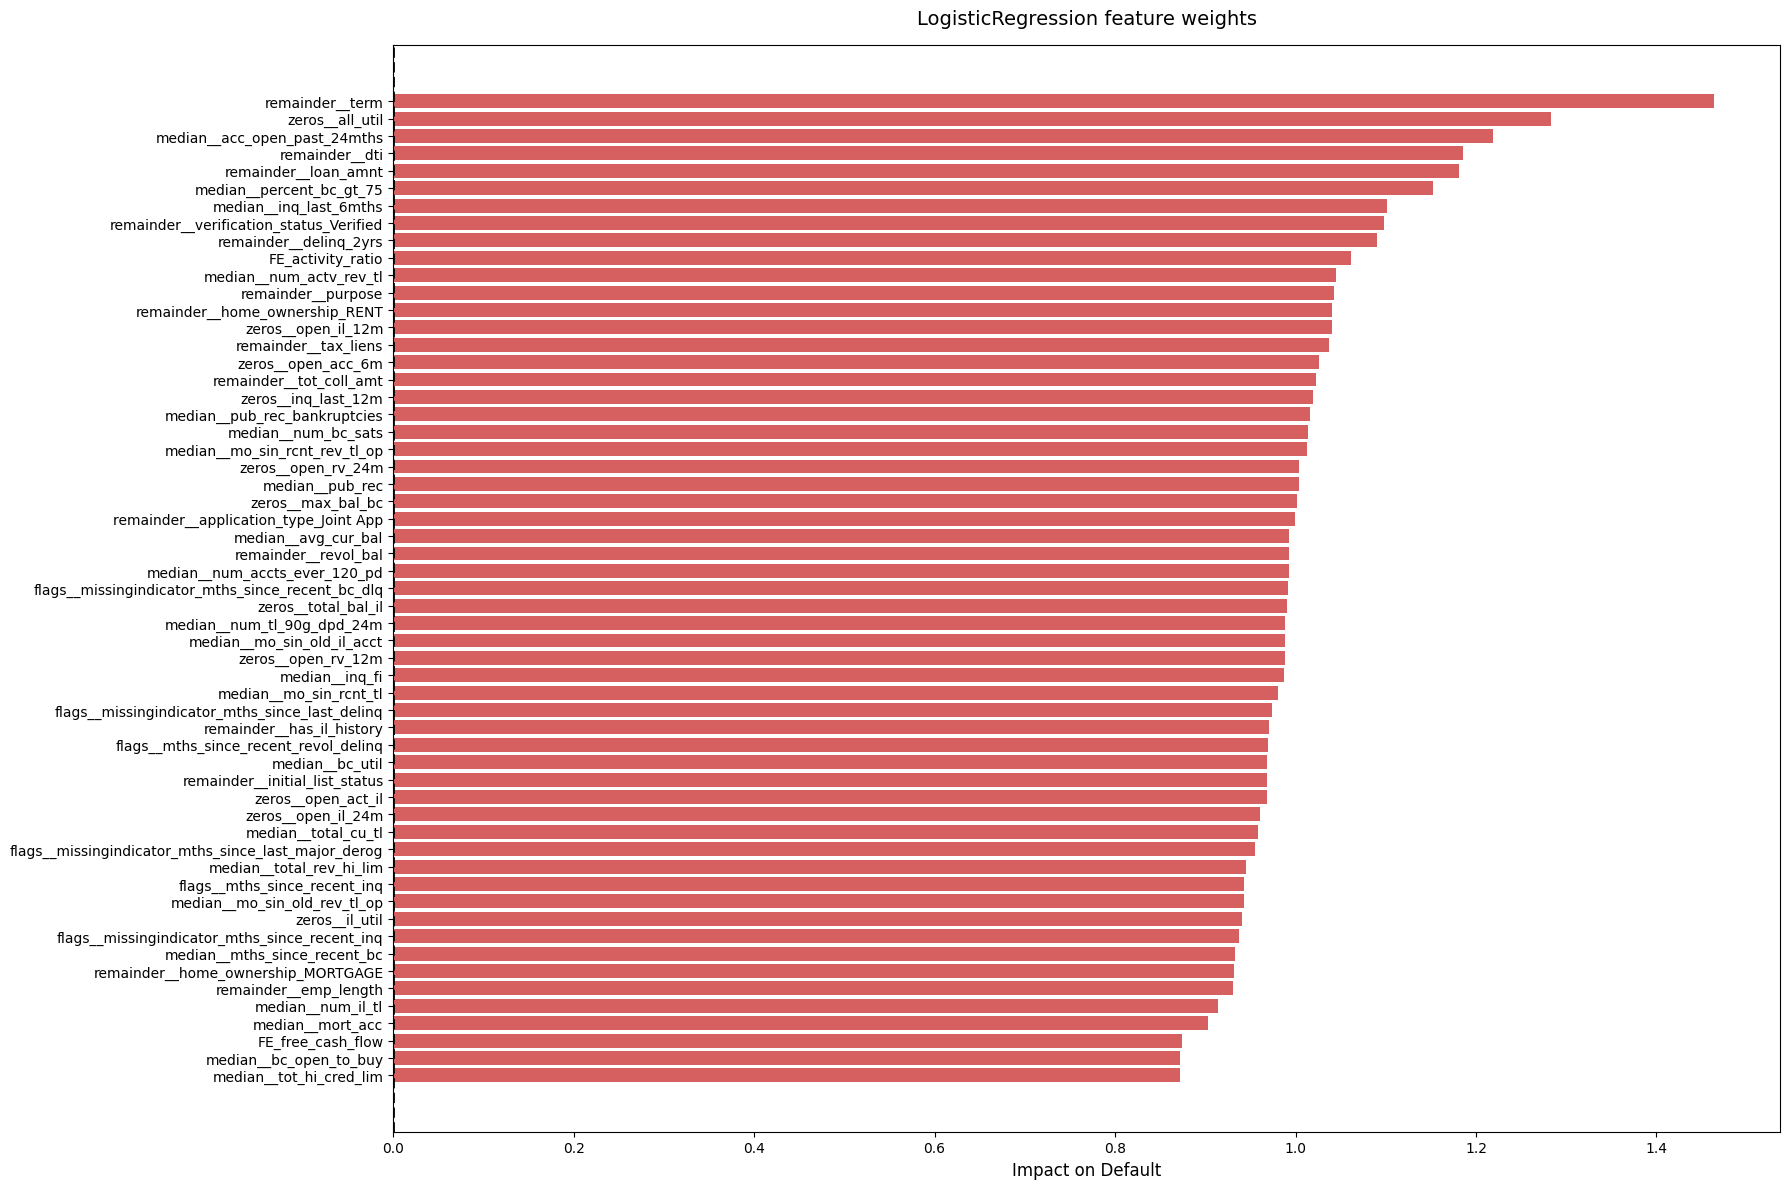

In [18]:
plt.figure(figsize=(18,12))
colors = ['#d65f5f' if c>0 else '#4878d0' for c in mr['odds']]

plt.barh(mr['Feature'], mr['odds'],color=colors)
plt.axvline(x=0,color='black',linestyle='--',linewidth=2)
plt.title('LogisticRegression feature weights',fontsize=14,pad=15)
plt.xlabel('Impact on Default',fontsize=12)
plt.savefig('Images/LogisticRegression_feature_weight.png',dpi=300,bbox_inches='tight')

plt.tight_layout()
plt.show()



H-Statistic to show how one feature contributes to other